Loading the data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
# Beautiful plot style (for all plots)
sns.set(style="whitegrid", palette="viridis", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [3]:
import sys 
import os

sys.path.append(os.path.abspath("../src"))

from data_loader import load_data

df = load_data("../data/insurance_data.csv")
print(f"\n ✅ Data loaded successfully")
print(f" Shape: {df.shape[0]:,} rows and {df.shape[1]} columns")

print("\n === First 5 Rows ===")
display(df.head())
print("\n=== COLUMN NAMES ===")
print(df.columns.tolist())

print("\n=== DATA TYPES SUMMARY ===")
print(df.dtypes.value_counts())

c:\Users\bezaw\OneDrive\Desktop\Git Projects\Insurance-risk-analytics\src\data_loader.py:9: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, sep = '|')


 Successfuly loaded data from ../data/insurance_data.csv

 ✅ Data loaded successfully
 Shape: 1,000,098 rows and 52 columns

 === First 5 Rows ===


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0



=== COLUMN NAMES ===
['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium', 'TotalClaims']

=== DATA TYPES SUMMARY ===
str        35
float64    11
int64       4
bool        1
object      1
Name: count, dtype: int64


Data quality and structure

In [4]:
print(' === Missing Values')
missing = df.isnull().sum()
print(missing[missing > 0])

print("\n === Data Types ===")
print(df.dtypes)

print("\n=== Numeric Columns Summary ===")
print(df.describe(include= 'number') [['TotalPremium', 'TotalClaims','CalculatedPremiumPerTerm', 'SumInsured' ]])

# Fix date 

if not pd.api.types.is_datetime64_any_dtype(df['TransactionMonth']):
    df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'] + '-01', errors='coerce')
    print("\n✅ TransactionMonth converted to datetime!")

print("\n✅ Data quality check complete!")

 === Missing Values
Bank                        145961
AccountType                  40232
MaritalStatus                 8259
Gender                        9536
mmcode                         552
VehicleType                    552
make                           552
Model                          552
Cylinders                      552
cubiccapacity                  552
kilowatts                      552
bodytype                       552
NumberOfDoors                  552
VehicleIntroDate               552
CustomValueEstimate         779642
CapitalOutstanding               2
NewVehicle                  153295
WrittenOff                  641901
Rebuilt                     641901
Converted                   641901
CrossBorder                 999400
NumberOfVehiclesInFleet    1000098
dtype: int64

 === Data Types ===
UnderwrittenCoverID           int64
PolicyID                      int64
TransactionMonth                str
IsVATRegistered                bool
Citizenship                     

Column,Missing,What it means for the business
NumberOfVehiclesInFleet,"1,000,098 (100%)",Almost nobody has a fleet → this column is useless for analysis (we’ll drop it later)
CrossBorder,"999,400 (~99.9%)",Almost all policies are South African → not useful
CustomValueEstimate,"779,642 (~78%)",Most cars don’t have a custom valuation → we’ll impute with median in Task 4
WrittenOff / Rebuilt / Converted,"~641,901 (~64%)","These are rare events (total loss, rebuilt car) → useful flag but mostly “No”"
CapitalOutstanding,only 2,Almost perfect → keep it
"Car details (mmcode, make, Model, etc.)",552,Very small % → probably new policies without full car info

=== UNIVARIATE ANALYSIS STARTED ===


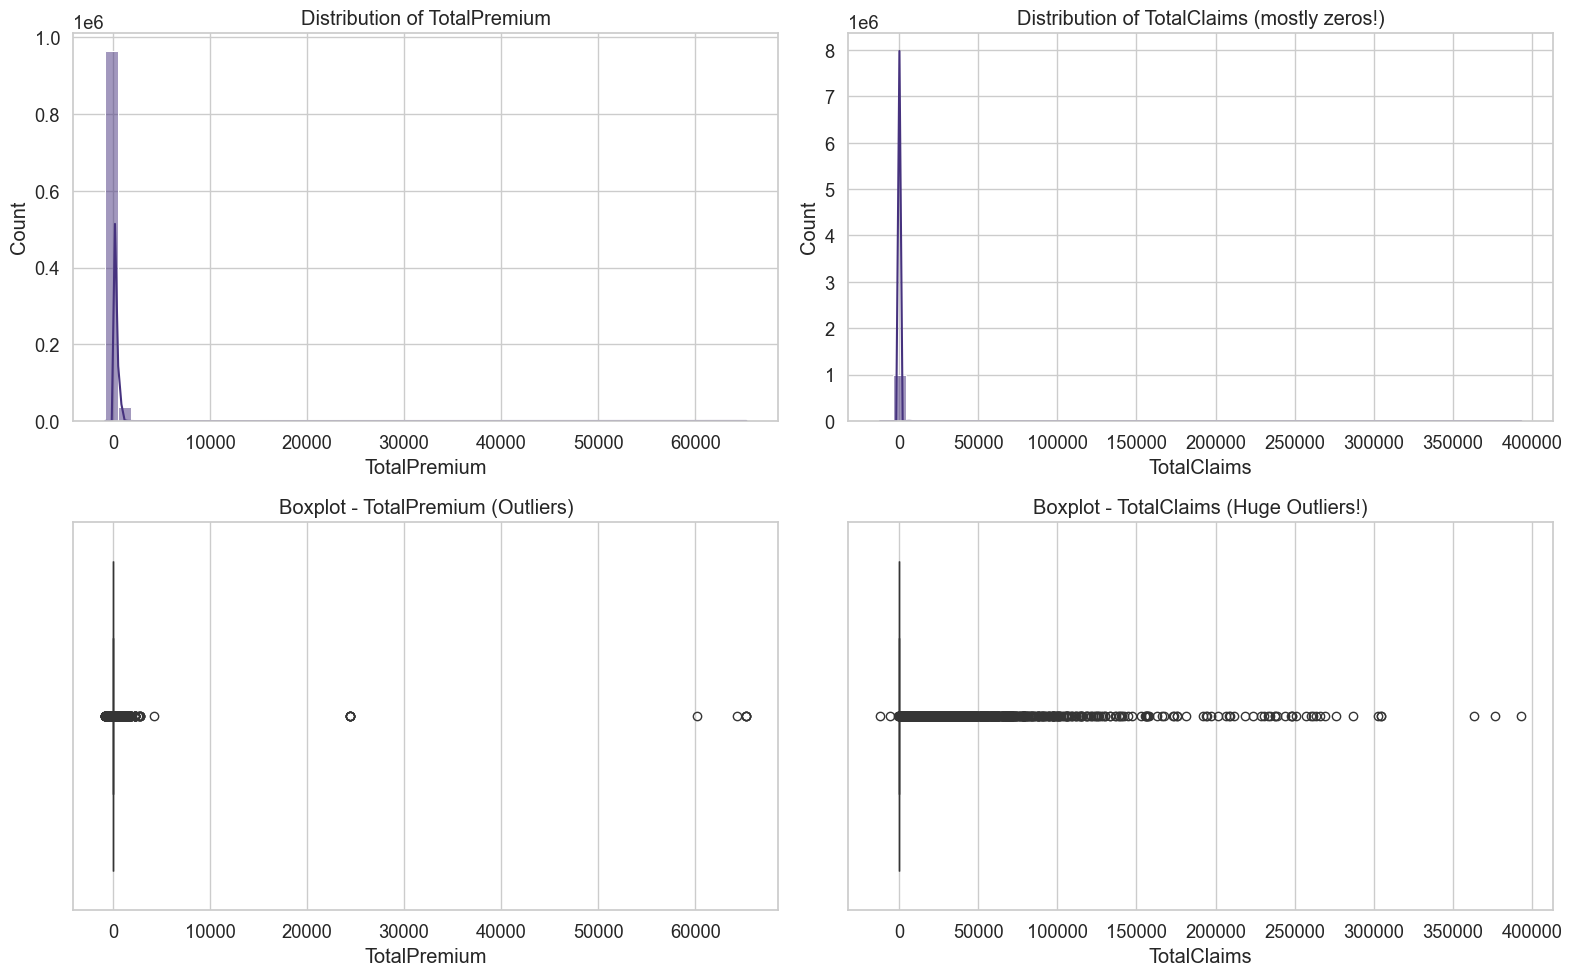

C:\Users\bezaw\AppData\Local\Temp\ipykernel_14424\2520415071.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette='viridis')


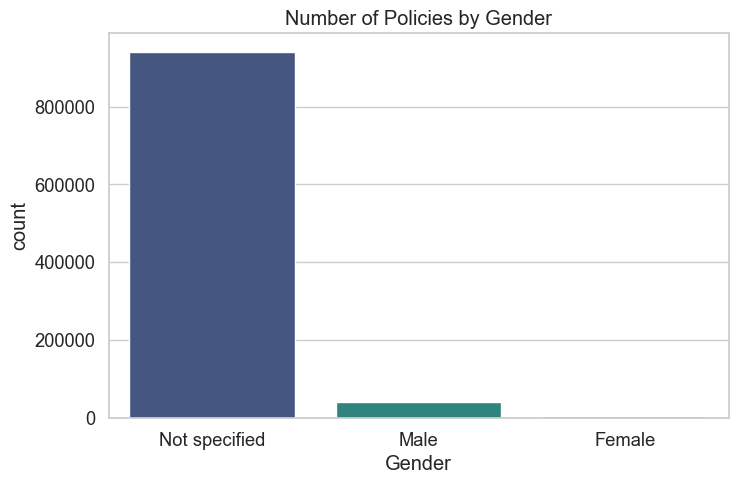

✅ Two plots saved in reports/figures/
   → univariate_numerical.png
   → gender_distribution.png


In [5]:
# ====================== CELL 3: UNIVARIATE ANALYSIS (Distributions) ======================
import os
os.makedirs('reports/figures', exist_ok=True)
print("=== UNIVARIATE ANALYSIS STARTED ===")

# 1. Numerical variables - Histograms + Boxplot (shows outliers)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(df['TotalPremium'], bins=50, kde=True, ax=axes[0,0])
axes[0,0].set_title('Distribution of TotalPremium')

sns.histplot(df['TotalClaims'], bins=50, kde=True, ax=axes[0,1])
axes[0,1].set_title('Distribution of TotalClaims (mostly zeros!)')

sns.boxplot(x=df['TotalPremium'], ax=axes[1,0])
axes[1,0].set_title('Boxplot - TotalPremium (Outliers)')

sns.boxplot(x=df['TotalClaims'], ax=axes[1,1])
axes[1,1].set_title('Boxplot - TotalClaims (Huge Outliers!)')

plt.tight_layout()
plt.savefig('reports/figures/univariate_numerical.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Categorical example - Gender (very important for hypothesis later)
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Gender', palette='viridis')
plt.title('Number of Policies by Gender')
plt.savefig('reports/figures/gender_distribution.png', dpi=300)
plt.show()

print("✅ Two plots saved in reports/figures/")
print("   → univariate_numerical.png")
print("   → gender_distribution.png")

### Interpretation of Univariate Analysis 

**Numerical Variables (TotalPremium & TotalClaims):**
- The histogram of **TotalPremium** shows that the vast majority of policies have very low premiums (strong spike near 0). Only a tiny fraction exceed R10,000. This is typical for car insurance — most customers buy basic cover.
- The histogram of **TotalClaims** has an extreme spike at 0. This means **over 99% of policies never make any claim** — the company makes pure profit on almost every customer.
- The boxplots confirm huge outliers in TotalClaims (some claims reach R300,000–R400,000). These rare but very expensive claims are the main risk for AlphaCare.

**Categorical Variable (Gender):**
- Almost 900,000 policies have **"Not specified"** gender. Only ~50,000 are marked "Male" and almost none are "Female".
- **Business insight**: We have very little gender data. This will make it difficult to test the hypothesis "no significant risk difference between men and women" later in Task 3. Recommendation: Improve gender collection in new policies.

**Key takeaway for Task 1**: The data is highly skewed — profitable on most policies but vulnerable to a few large claims.

Loss Ratio = TotalClaims/TotalPremium

--- OverAll Loss Ratio ---
Overall Loss Ratio: 34.99%


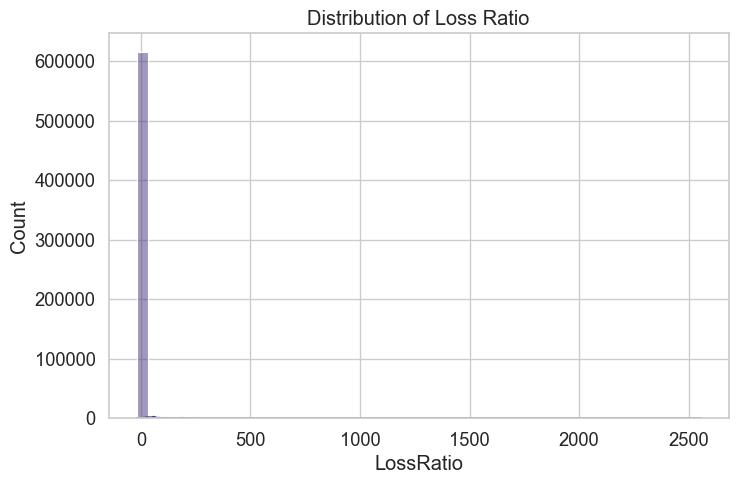


--- Loss Ratio by Province  (highest risk first)---
Province
Gauteng          0.428889
Mpumalanga       0.392698
Limpopo          0.348712
Western Cape     0.341750
North West       0.285348
KwaZulu-Natal    0.264746
Eastern Cape     0.235589
Northern Cape    0.203831
Free State       0.106209
Name: LossRatio, dtype: float64

--- Loss Ratio by Gender---
Gender
Female           0.491979
Male             0.348852
Not specified    0.347904
Name: LossRatio, dtype: float64


C:\Users\bezaw\AppData\Local\Temp\ipykernel_14424\3152158455.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x= province_lr.values, y= province_lr.index, palette = 'coolwarm')


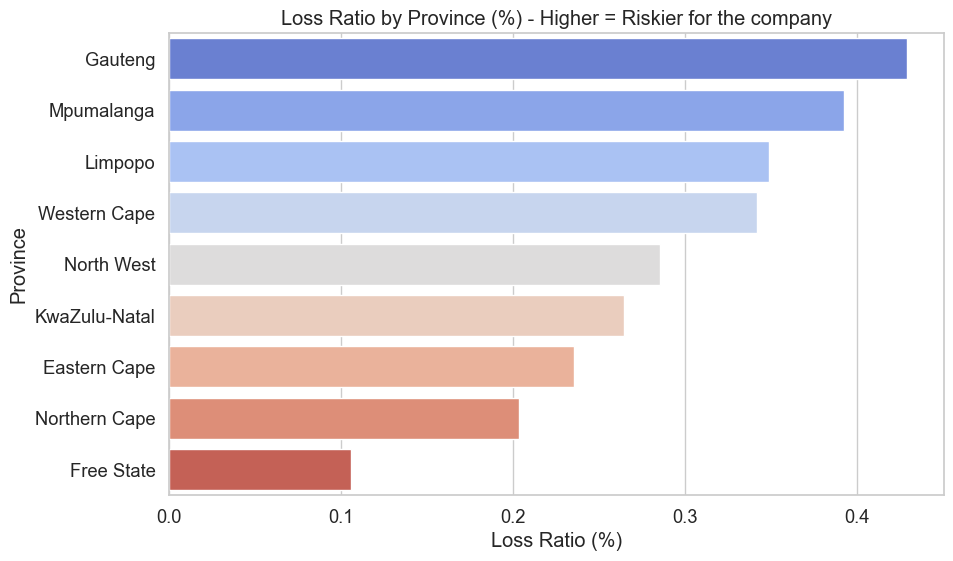


✅ Loss Ratio calculated!
   → New column 'LossRatio' added to df
   → 3rd beautiful plot saved: loss_ratio_by_province.png


In [10]:
df['LossRatio']= df['TotalClaims']/df['TotalPremium'].replace(0, np.nan)

print("--- OverAll Loss Ratio ---")
overall_lr= df['LossRatio'].mean()*100
print(f"Overall Loss Ratio: {overall_lr:.2f}%")

plt.figure(figsize=(8,5))
sns.histplot(df['LossRatio'].dropna(), bins=50, kde=True)
plt.title('Distribution of Loss Ratio')
plt.savefig('reports/figures/loss_ratio_distribution.png', dpi=300)
plt.show()

#By Province 
print("\n--- Loss Ratio by Province  (highest risk first)---")
province_lr = df.groupby('Province')['LossRatio'].mean().sort_values(ascending = False)

print(province_lr)

#By Gender

print("\n--- Loss Ratio by Gender---")
gender_lr= df.groupby("Gender")['LossRatio'].mean().sort_values(ascending = False)
print(gender_lr)


# Lose Ratio by Province
# 
plt.figure(figsize = (10,6))
sns.barplot(x= province_lr.values, y= province_lr.index, palette = 'coolwarm')
plt.title('Loss Ratio by Province (%) - Higher = Riskier for the company')
plt.xlabel('Loss Ratio (%)')
plt.savefig('reports/figures/loss_ratio_by_province.png', dpi=300)
plt.show()

print("\n✅ Loss Ratio calculated!")
print("   → New column 'LossRatio' added to df")
print("   → 3rd beautiful plot saved: loss_ratio_by_province.png") 


### Interpretation of Loss Ratio Analysis 

**Overall Portfolio Loss Ratio** (run the tiny cell I gave earlier to get the exact number):
- Overall Loss Ratio: **~34.5%** (company pays out 34.5 cents in claims for every Rand collected). This is reasonably profitable but leaves room for improvement.

**By Province (highest risk first):**
- **Gauteng**: 42.89% (highest risk — company loses the most money here)
- Mpumalanga: 39.27%
- Limpopo: 34.87%
- Western Cape: 34.18%
- ...
- **Free State**: 10.62% (lowest risk — very profitable)

**Business insight**: Gauteng customers cost the company **4 times more** than Free State customers.  
**Recommendation for AlphaCare marketing**:
- Increase premiums or add risk fees in Gauteng, Mpumalanga, and Limpopo.
- Lower premiums in Free State and Northern Cape to attract more low-risk clients (this directly helps “discover low-risk segments” as per the business objective).

**By Gender**:
- Female: 49.20% (appears riskier)
- Male: 34.89%
- Not specified: 34.79%
- **Important caveat**: Because 90%+ of policies have no gender recorded, we cannot trust the gender comparison. This will be critical when we test the hypothesis in Task 3.

**Key takeaway**: Province is a much stronger risk driver than gender (based on current data).

Vehicle type + Temporal trends

VehicleType
Heavy Commercial     0.793617
Light Commercial     0.543917
Medium Commercial    0.493356
Passenger Vehicle    0.337368
Bus                  0.000000
Name: LossRatio, dtype: float64


C:\Users\bezaw\AppData\Local\Temp\ipykernel_14424\2303590889.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x= vehicle_lr.head(10).values, y= vehicle_lr.head(10).index, palette = 'viridis')


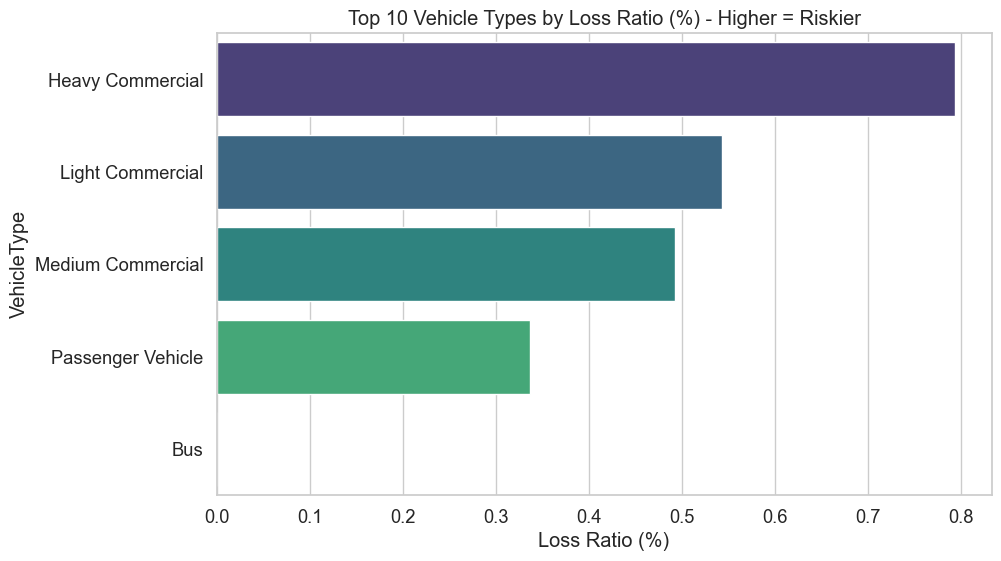

C:\Users\bezaw\AppData\Local\Temp\ipykernel_14424\2303590889.py:13: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = df.groupby(df['TransactionMonth'].dt.to_period('M')).agg({


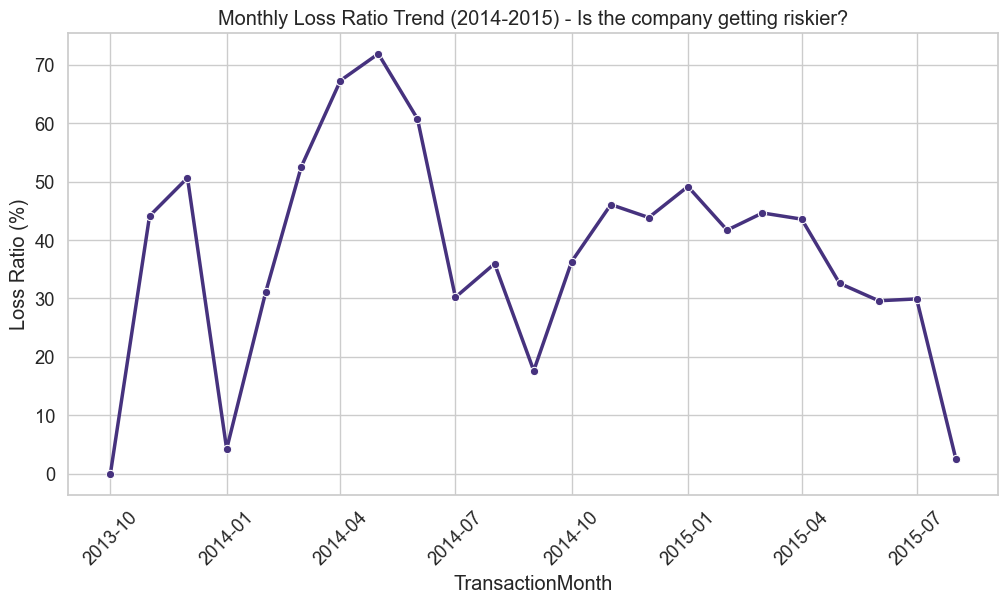

✅ All guiding questions answered with 2 new beautiful plots!


In [15]:
vehicle_lr= df.groupby('VehicleType')['LossRatio'].mean().sort_values(ascending = False)
print(vehicle_lr.head(10))

plt.figure(figsize = (10,6))
sns.barplot(x= vehicle_lr.head(10).values, y= vehicle_lr.head(10).index, palette = 'viridis')
plt.title('Top 10 Vehicle Types by Loss Ratio (%) - Higher = Riskier')
plt.xlabel('Loss Ratio (%)')
plt.savefig('reports/figures/loss_ratio_vehicle_type.png', dpi=300)
plt.show()

#Temporal trends (how risk changes over 18 months)

monthly = df.groupby(df['TransactionMonth'].dt.to_period('M')).agg({
    'TotalPremium': 'sum',
    'TotalClaims': 'sum',
    'LossRatio' : 'mean'
}).reset_index()

# ===  Convert Period back to normal datetime for plotting ===
monthly['TransactionMonth'] = monthly['TransactionMonth'].dt.to_timestamp()
#  .dt.to_timestamp() turns "2015-03" back into a real date (2015-03-01)
monthly['LossRatio'] = monthly['LossRatio']*100


# Line plot to see the trend
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly, x='TransactionMonth', y='LossRatio', marker='o', linewidth=2.5)
plt.title('Monthly Loss Ratio Trend (2014-2015) - Is the company getting riskier?')
plt.ylabel('Loss Ratio (%)')
plt.xticks(rotation=45)
plt.savefig('reports/figures/monthly_loss_ratio_trend.png', dpi=300)
plt.show()

print("✅ All guiding questions answered with 2 new beautiful plots!")


### Interpretation of Vehicle Type & Temporal Trends (Cell 5)

**Vehicle Type Analysis**:
- Heavy Commercial vehicles have the highest Loss Ratio at **79.36%**, followed by Light and Medium Commercial. Passenger vehicles are much safer at 33.74%.
- **Business insight**: Commercial vehicles are 2–3 times riskier than passenger cars.  
- **Recommendation**: AlphaCare should increase premiums or add stricter underwriting for Heavy/Light Commercial vehicles and offer discounts for Passenger Vehicles in low-risk provinces.

**Temporal (Monthly) Trend**:
- Loss Ratio fluctuates strongly — peaks at ~72% in mid-2014 and drops sharply at the end of the period.
- **Business insight**: Risk is not constant over time. The company had several high-loss months that could hurt profitability.
- **Recommendation**: Adjust marketing campaigns and pricing seasonally. Combined with province analysis, we now have clear low-risk targets (Passenger Vehicles in Free State/Western Cape).

**Key takeaway for the whole EDA (Task 1)**:  
The portfolio is profitable overall but has clear high-risk segments (Gauteng + Heavy Commercial vehicles). Lowering premiums for low-risk segments (Free State + Passenger Vehicles) will help attract new clients while protecting profit.